<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/PortfolioAnalysis/PortfolioAnalysis/Sharpe%2C_Sortino%2C_Max_Drawdown_Calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

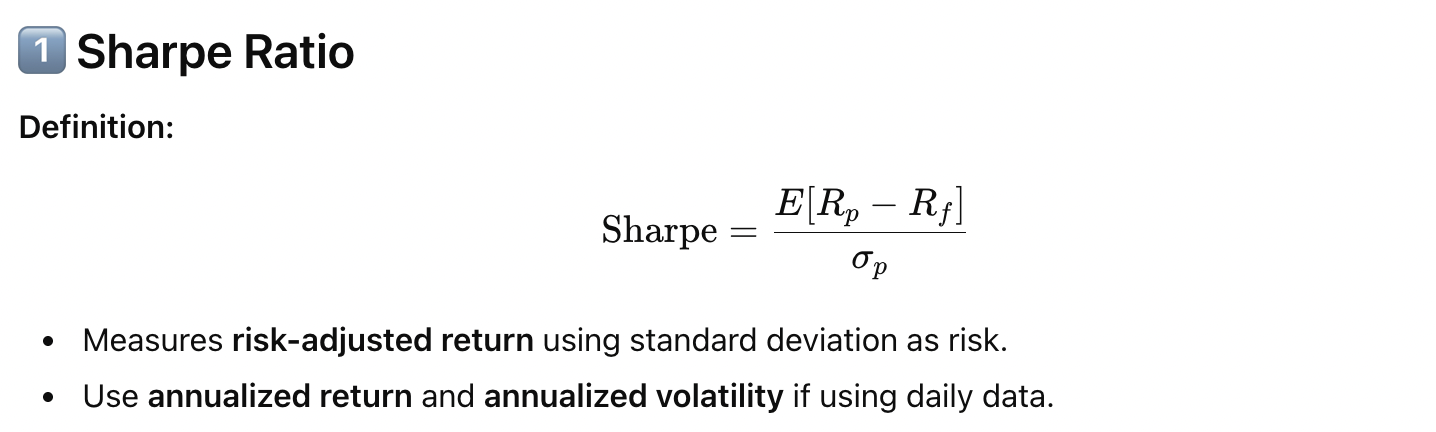

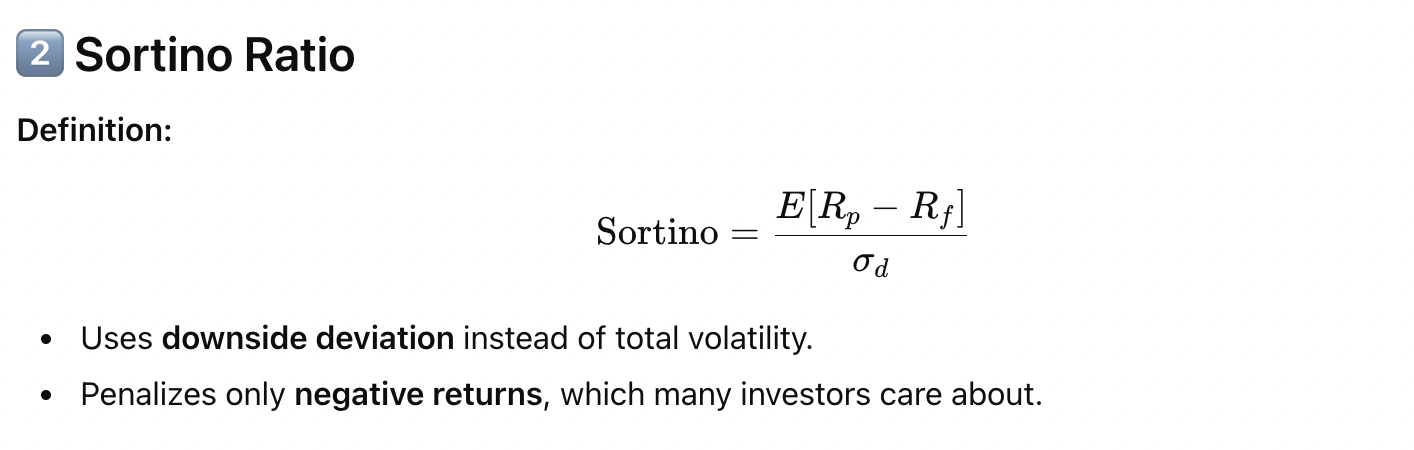

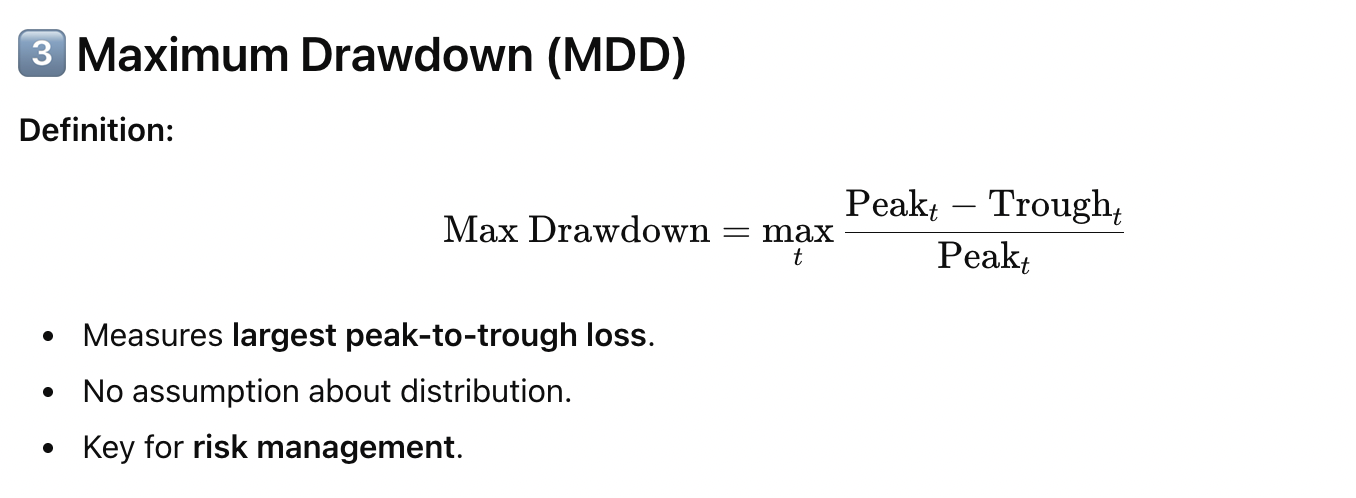

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", end="2025-01-01", freq='B')  # business days
n_days = len(dates)

# Simulate prices using geometric Brownian motion
def simulate_prices(S0, mu, sigma, n):
    """S0: initial price, mu: daily return, sigma: daily volatility, n: days"""
    dt = 1
    returns = np.random.normal(loc=mu, scale=sigma, size=n)
    prices = S0 * np.exp(np.cumsum(returns))
    return prices

# Portfolio of 3 assets
prices = pd.DataFrame({
    'Stock_A': simulate_prices(100, 0.0005, 0.01, n_days),
    'Stock_B': simulate_prices(50, 0.0003, 0.008, n_days),
    'Stock_C': simulate_prices(200, 0.0004, 0.012, n_days),
}, index=dates)

prices.head()

,Stock_A,Stock_B,Stock_C
2023-01-02,100.548211,50.243832,201.652363
2023-01-03,100.459502,49.952958,197.952784
2023-01-04,101.162848,49.251640,201.572077
2023-01-05,102.766751,48.629110,205.020119
2023-01-06,102.577677,48.662417,203.568257


In [ ]:
returns = prices.pct_change().dropna()  # daily percentage change
returns.head()

,Stock_A,Stock_B,Stock_C
2023-01-03,-0.000882,-0.005789,-0.018346
2023-01-04,0.007001,-0.014040,0.018284
2023-01-05,0.015855,-0.012640,0.017106
2023-01-06,-0.001840,0.000685,-0.007082
2023-01-09,-0.001840,0.002381,0.005163


In [ ]:
weights = np.array([1/3, 1/3, 1/3])
returns['Portfolio'] = returns.dot(weights)
returns.head()

,Stock_A,Stock_B,Stock_C,Portfolio
2023-01-03,-0.000882,-0.005789,-0.018346,-0.008339
2023-01-04,0.007001,-0.014040,0.018284,0.003748
2023-01-05,0.015855,-0.012640,0.017106,0.006774
2023-01-06,-0.001840,0.000685,-0.007082,-0.002745
2023-01-09,-0.001840,0.002381,0.005163,0.001901


In [ ]:
class PortfolioMetrics:
    def __init__(self, returns, rf=0.0, periods_per_year=252):
        if not isinstance(returns, pd.Series):
            returns = pd.Series(returns)
        self.returns = returns
        self.rf = rf
        self.periods = periods_per_year
        self.cumulative = (1 + self.returns).cumprod()

    def sharpe_ratio(self):
        excess = self.returns - self.rf / self.periods
        mean_excess = excess.mean() * self.periods
        vol = excess.std() * np.sqrt(self.periods)
        return mean_excess / vol

    def sortino_ratio(self):
        excess = self.returns - self.rf / self.periods
        mean_excess = excess.mean() * self.periods
        downside = excess[excess < 0]
        downside_vol = np.sqrt((downside ** 2).mean()) * np.sqrt(self.periods) if len(downside) > 0 else 1e-8
        return mean_excess / downside_vol

    def max_drawdown(self):
        peak = self.cumulative.cummax()
        drawdown = (self.cumulative - peak) / peak
        return drawdown.min()

    def rolling_sharpe(self, window=252):
        return self.returns.rolling(window).apply(lambda x: PortfolioMetrics(x, self.rf, self.periods).sharpe_ratio(), raw=False)

    def rolling_sortino(self, window=252):
        return self.returns.rolling(window).apply(lambda x: PortfolioMetrics(x, self.rf, self.periods).sortino_ratio(), raw=False)

    def rolling_max_drawdown(self, window=252):
        return self.returns.rolling(window).apply(lambda x: PortfolioMetrics(x, self.rf, self.periods).max_drawdown(), raw=False)

    def plot_cumulative(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.cumulative, label='Cumulative Returns')
        plt.title('Portfolio Cumulative Returns')
        plt.xlabel('Date'); plt.ylabel('Cumulative Return')
        plt.legend(); plt.grid(True)
        plt.show()

    def plot_drawdown(self):
        peak = self.cumulative.cummax()
        drawdown = (self.cumulative - peak) / peak
        plt.figure(figsize=(10,5))
        plt.plot(drawdown, color='red', label='Drawdown')
        plt.title('Portfolio Drawdown')
        plt.xlabel('Date'); plt.ylabel('Drawdown')
        plt.legend(); plt.grid(True)
        plt.show()

    def summary(self):
        print("Portfolio Metrics Summary:")
        print(f"Sharpe Ratio: {self.sharpe_ratio():.2f}")
        print(f"Sortino Ratio: {self.sortino_ratio():.2f}")
        print(f"Max Drawdown: {self.max_drawdown():.2%}")

Portfolio Metrics Summary:
Sharpe Ratio: 2.05
Sortino Ratio: 2.16
Max Drawdown: -6.00%


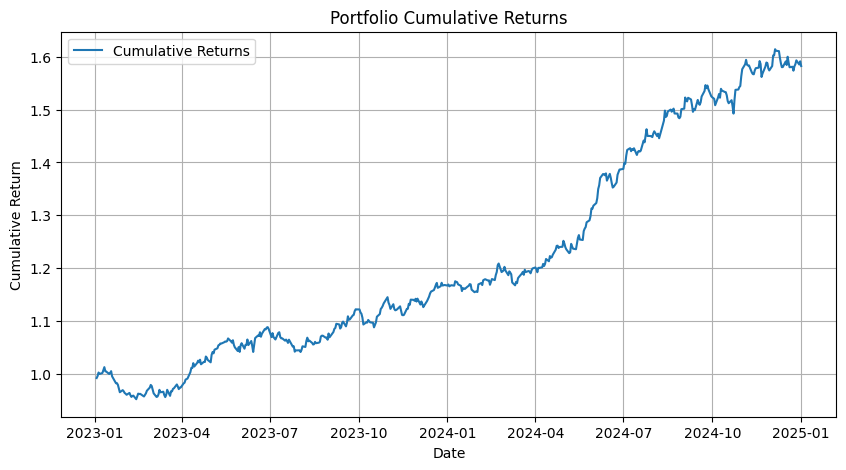

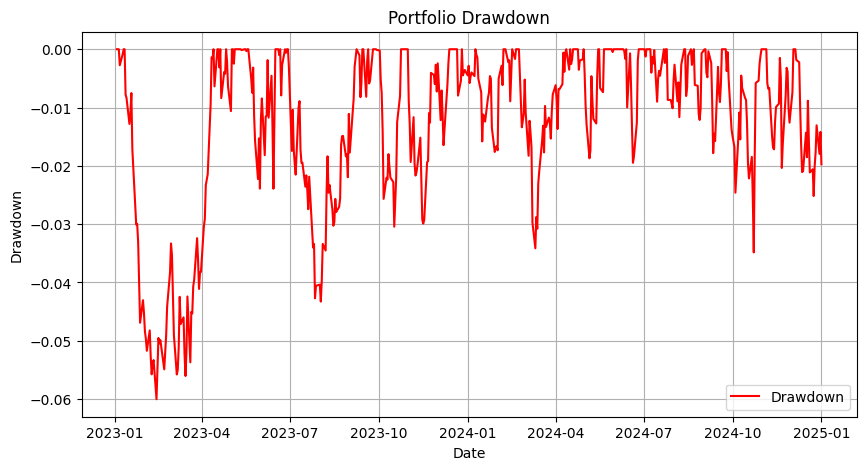

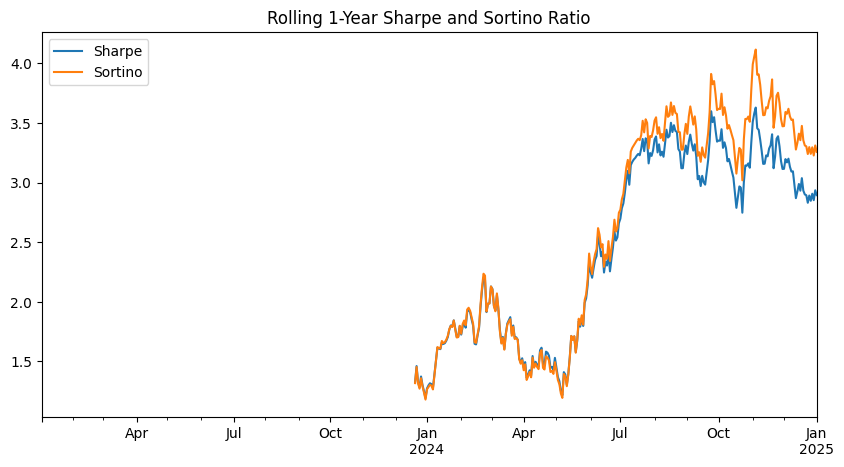

In [ ]:
rf_annual = 0.04
portfolio = PortfolioMetrics(returns['Portfolio'], rf=rf_annual)

# Summary
portfolio.summary()

# Plot cumulative returns
portfolio.plot_cumulative()

# Plot drawdowns
portfolio.plot_drawdown()

# Rolling 1-year Sharpe
rolling_sharpe = portfolio.rolling_sharpe(window=252)
rolling_sharpe.plot(title='Rolling 1-Year Sharpe Ratio', figsize=(10,5), label = 'Sharpe')
# plt.show()

# Rolling 1-year Sharpe
rolling_sortino = portfolio.rolling_sortino(window=252)
rolling_sortino.plot(title='Rolling 1-Year Sharpe and Sortino Ratio', figsize=(10,5), label = 'Sortino')
plt.legend()